# CLIP (Contrastive Language Image Pretraining)

Most machine learning models operate in single modality (only text, only images). Real-world understanding is multi-modal.

We can make a model understand images and text in a shared semantic space, using representation alignment.

#### Idea behind CLIP

1. Images can be converted into vectors.
2. Text can be converted into vectors.
3. If two things mean the same thing, their vectors should be close.
4. Distance in vector space = semantic similarity

CLIP does only this, at scale.

#### CLIP Architecture

CLIP has two encoders.
- Image: CNN or Vision Transformer
- Text: Transformer

Both ouput vectors of the same dimension.


The trainig data consists of pairs of [Image, Caption].

Given a batch of N image-text pairs:
- Each image should match its own caption.
- And mismatch all other captions

So for one image:
- 1 positive text
- N - 1 negative tests

Same logic in reverse for images.

#### Why is CLIP powerful?

CLIP never learns:
- fixed classes
- task-specific heads

Instead, it learns language grounding.


This leads to:
1. zero-shot classification
2. open-vocabulary recognition
3. image-text retrieval
4. prompt-based reasoning

In [1]:
# install the dependencies

!pip install torch torchvision ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.9 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-c91_km5k
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-c91_km5k
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=5d9b675b539dfc443961ab1a79eab202caf0ba8b3dae0130cde48437e3e9207c
  Stored in directory: /tmp/pip-ephem-wheel-cache-dyqc9oez/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [2]:
# load the model

import clip
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

model, preprocess = clip.load("ViT-B/32", device=device)

100%|████████████████████████████████████████| 338M/338M [00:01<00:00, 312MiB/s]


In [8]:
model.eval()

CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): Sequential(
        (0): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): QuickGELU()
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
        (1): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          

In [3]:
# encode the image

from PIL import Image

image = preprocess(Image.open("dog_input.jpeg")).unsqueeze(0).to(device)

with torch.no_grad():
  image_features = model.encode_image(image)

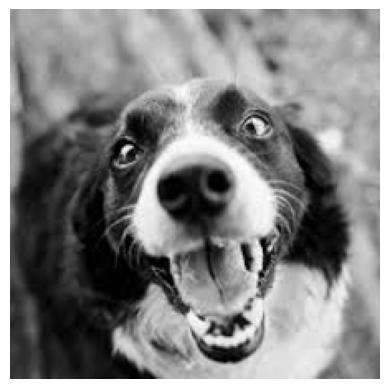

In [14]:
import matplotlib.pyplot as plt

image_np = image.cpu().squeeze(0).permute(1,2,0).numpy()
mean = [0.48145466, 0.4578275, 0.40821073]
std  = [0.26862954, 0.26130258, 0.27577711]
image_np = std * image_np + mean
image_np = image_np.clip(0,1)

plt.imshow(image_np)
plt.axis("off")
plt.show()

In [4]:
texts = clip.tokenize([
    "a photo of a dog",
    "a photo of a cat",
    "a photo of a car"
]).to(device)

with torch.no_grad():
    text_features = model.encode_text(texts)

## Zero shot classification

In [5]:
# normalise embeddings

image_features /= image_features.norm(dim=-1, keepdim=True)
text_features /= text_features.norm(dim=-1, keepdim=True)


In [6]:
# compute similarity
similarity = (image_features @ text_features.T).softmax(dim=-1)

In [7]:
templates = [
    "a photo of a {}",
    "a blurry photo of a {}",
    "a drawing of a {}"
]

texts = [t.format("dog") for t in templates]

In [10]:
for label, score in zip(texts, similarity[0]):
    print(label, score.item())

a photo of a dog 0.349365234375
a blurry photo of a dog 0.329345703125
a drawing of a dog 0.3212890625
